## Functional characterization analysis

## Gavish 3CA pathways

In [2]:
import gseapy as gp
import pandas as pd

## Please give the path of the gmt file of meta-programs information
gavish_pathways = pd.read_csv("/data/subhasis_backup/subhasis/functional_heterogeneity_pipeline/GSEA/c4.3ca.v2026.1.Hs.symbols.gmt", sep="\t", header=None)
pathways = gavish_pathways.iloc[:,0]

In [3]:
matches = pathways[pathways.str.contains('MALIGNANT|EPITHELIAL|T_CELLS|MACROPHAGES|ENDOTHELIAL|FIBROBLASTS')]
gavish_pathways = gavish_pathways.loc[gavish_pathways[0].isin(matches),:]

pathway_genes = {}

for idx, row in gavish_pathways.iterrows():
    pathway = row[0]           
    genes = row[2:].dropna()   
    pathway_genes[pathway] = genes.tolist()

In [4]:
len(pathway_genes.keys())

136

In [12]:
import os

def identify_specialist_generalist(sample_name):
    sample_name = sample_name
    
    ## Please give the full path where your TPM expression data is present
    exp_data_file = os.path.join(f"/data/subhasis_backup/subhasis/pipeline_testing/data/{sample_name}", (sample_name+"_TPM_mod.csv")) 
    exp_data = pd.read_csv(exp_data_file, index_col=0)
    
    ## Please give the full path of the folder where the result after mellon analysis are saved
    path = os.chdir(os.path.join("/data/subhasis_backup/subhasis/pipeline_testing/mellon_analysis/", sample_name))  
    files = os.listdir(path)
    specialist_generalist_files = []
    for file in files:
        if file.endswith("specialists_and_generalists.csv") == True:
            specialist_generalist_files.append(file)
    specialist_generalist_files.sort()
    
    specialist_generalist_cells = []
    for files in specialist_generalist_files:
        data = pd.read_csv(files,index_col=0)
        specialist_generalist_cells.append(data)
    return specialist_generalist_cells, exp_data, specialist_generalist_files

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def func_char_archetype(specialist_generalist_df, exp_data, sample_name):
    output_func_char_arch = identify_specialist_generalist(sample_name)
    combined_df = pd.concat(output_func_char_arch[0], axis=0)
    archetype_cells = specialist_generalist_df["cells"]
    other_cells = combined_df[~combined_df['cells'].isin(archetype_cells)]
    archetype_cells_exp_data = exp_data.loc[:,exp_data.columns.isin(archetype_cells)]
    other_cells_exp_data = exp_data.loc[:,exp_data.columns.isin(other_cells.cells)]

    pathway_archetype = {}
    for pathway, genes in pathway_genes.items():
        # Keep only genes that exist in the expression matrix
        valid_genes_archetype = [g for g in genes if g in archetype_cells_exp_data.index]
    
        # Sum expression across these genes for each cell
        pathway_archetype[pathway] = archetype_cells_exp_data.loc[valid_genes_archetype].mean(axis=0)

    pathway_others = {}
    for pathway, genes in pathway_genes.items():

        valid_genes_other_cells = [g for g in genes if g in other_cells_exp_data.index]
    
        # Sum expression across these genes for each cell
        pathway_others[pathway] =  other_cells_exp_data.loc[valid_genes_other_cells].mean(axis=0)
    
    # Convert to dataframe (rows = pathways, columns = cells)
    pathway_expression_archetype = pd.DataFrame(pathway_archetype).T
    pathway_expression_others = pd.DataFrame(pathway_others).T

    return (pathway_expression_archetype, pathway_expression_others)


def perform_differential_analysis(archetype_df, rest_df, q_threshold=0.1):
    archetype_df = archetype_df.loc[rest_df.index]
    
    p_values = []
    stats = []
    log2_fc = []
    
    features = rest_df.index.tolist()
    for feature in features:
        # Get values for this feature across all samples in each group
        vals_arch = archetype_df.loc[feature].values
        vals_rest = rest_df.loc[feature].values
        
        # Mann-Whitney U Test (Non-parametric)
        stat, p = mannwhitneyu(vals_arch, vals_rest, alternative='two-sided')
        
        # Calculate Log2 Fold Change (to know if it's UP or DOWN)
        mean_arch = np.mean(vals_arch)
        mean_rest = np.mean(vals_rest)
        lfc = np.log2((mean_arch + 1e-9) / (mean_rest + 1e-9))
        
        p_values.append(p)
        stats.append(stat)
        log2_fc.append(lfc)

    results = pd.DataFrame({
        'Feature': features,
        'P_Value': p_values,
        'Log2FC': log2_fc,
        'U_Stat': stats
    })
    
    # FDR Correction (Benjamini-Hochberg)
    reject, q_values, _, _ = multipletests(results['P_Value'], alpha=q_threshold, method='fdr_bh')
    
    results['Q_Value'] = q_values
    
    sig_results = results[results   ['Q_Value'] < q_threshold].copy()
    
    sig_results['Direction'] = sig_results['Log2FC'].apply(
        lambda x: 'Enriched in Archetype' if x > 0 else 'Enriched in Rest'
    )

    archetype_direction = sig_results[sig_results["Direction"]=="Enriched in Archetype"]
    archetype_direction = archetype_direction.sort_values('Q_Value', ascending=True)
    rest_direction = sig_results[sig_results["Direction"]=="Enriched in Rest"]
    rest_direction = rest_direction.sort_values('Q_Value', ascending=True)

    sig_results_mod = pd.concat([archetype_direction, rest_direction], axis=0)
    return sig_results_mod

In [14]:
import os
import gc           
import traceback    

## Please give the full path where you want to save files generated from functional characterization analysis. Put that path in "base_output_folder".
def process_and_save_samples(sample_list, base_output_folder="/data/subhasis_backup/subhasis/pipeline_testing/functional_characterization_gavish_test/"):    
    os.makedirs(base_output_folder, exist_ok=True)

    for sample in sample_list:
        print(f"\n>>> PROCESSING SAMPLE: {sample} ==================")
        
        try:
            sample_folder = os.path.join(base_output_folder, sample)
            os.makedirs(sample_folder, exist_ok=True)
            
            out_1 = identify_specialist_generalist(sample)
            specialist_generalist_data = out_1[0]
            final_result = []
            file_name = []
            for i in range(len(specialist_generalist_data)):
                
                specialist_df, others_df = func_char_archetype(specialist_generalist_data[i], out_1[1], sample)
                
                result = perform_differential_analysis(specialist_df, others_df, q_threshold=0.1)        
                filename = out_1[2][i]
                filename = filename.split('.', 1)[0]
                final_result.append(result)
                file_name.append(filename)
                
            result_dfs = final_result
            print(f"  -> Saving files to: {sample_folder}")
            
            for j in range(len(result_dfs)):
                save_path = os.path.join(sample_folder, f"{file_name[j]}.csv")
    
                result_dfs[j].to_csv(save_path, index=False)
                print(f"     Saved: {file_name}")

            print(f">>> SUCCESS: {sample} finished.")

        except Exception as e:
            print(f"!!! ERROR on {sample}: {e}")
            traceback.print_exc()
            
        finally:
            if 'result_dfs' in locals(): del result_dfs         
            gc.collect() 
            print("  -> Memory cleaned.")

if __name__ == "__main__":
    my_samples = ["SMC01-N", "SMC01-T", "SMC02-T", "SMC03-N", "SMC03-T", "SMC04-N", "SMC04-T", "SMC05-N", "SMC05-T", "SMC06-N", "SMC06-T",
                  "SMC07-N", "SMC07-T", "SMC08-N", "SMC08-T", "SMC09-N", "SMC09-T", "SMC10-N", "SMC10-T", "SMC11-T", "SMC14-T", "SMC15-T", "SMC16-T",
                  "SMC17-T", "SMC18-T", "SMC19-T", "SMC20-T", "SMC21-T", "SMC22-T", "SMC23-T", "SMC24-T", "SMC25-T"]
    
    process_and_save_samples(my_samples)


>>> PROCESSING SAMPLE: SMC01-N ==================
  -> Saving files to: /data/subhasis_backup/subhasis/pipeline_testing/functional_characterization_gavish_test/SMC01-N
     Saved: ['Archetype_1_specialists_mellon_high_density_specialists_and_generalists', 'Archetype_2_0_specialists_cluster_0_mellon_high_density_specialists_and_generalists', 'Archetype_2_1_specialists_cluster_1_mellon_high_density_specialists_and_generalists', 'Archetype_2_2_specialists_cluster_2_mellon_high_density_specialists_and_generalists', 'Archetype_2_3_specialists_cluster_3_mellon_high_density_specialists_and_generalists', 'Archetype_2_4_specialists_cluster_4_mellon_high_density_specialists_and_generalists', 'Archetype_2_5_specialists_cluster_5_mellon_high_density_specialists_and_generalists', 'Archetype_2_6_specialists_cluster_6_mellon_high_density_specialists_and_generalists', 'Archetype_3_specialists_mellon_high_density_specialists_and_generalists', 'Archetype_4_specialists_mellon_high_density_specialists_an

## Functional characterization based on meta-programs (Gavish) cell type wise

In [37]:
import os

def identify_specialist_generalist(sample_name):
    sample_name = sample_name
    path = os.chdir(os.path.join("/data/subhasis_backup/subhasis/pipeline_testing/mellon_celltype_specialist_generalist", sample_name))
    files = os.listdir(path)
    specialist_generalist_files = []
    for file in files:
        if file.endswith(".csv") == True:
            specialist_generalist_files.append(file)
    specialist_generalist_files.sort()

    specialist_generalist_cells = []
    for files in specialist_generalist_files:
        data = pd.read_csv(files,index_col=0)
        specialist_generalist_cells.append(data)
    
    extracted_celltype = []
    specialist_generalist_files_mod = []
    
    for i, df in enumerate(specialist_generalist_cells):
        # Please change the celltype 'Epithelial' to other as per choice. 
        # But this cell type name should be exactly matched with the column present in "mellon_celltype_specialist_generalist folder.
        valid_count = df['Epithelial'].notna() & (df['Epithelial'] != '')     
        df_celltype = df[df['Epithelial'].notna() & (df['Epithelial'] != '')]
        
        if valid_count.sum() > 1:
            extracted_celltype.append(df_celltype['Epithelial'])
            specialist_generalist_files_mod.append(specialist_generalist_files[i])
    
    specialist_generalist_files_mod.sort()
    return extracted_celltype, specialist_generalist_files_mod

### Functional emergence with cancer progression

In [42]:
from functools import reduce
import os
import pandas as pd

def sample_hallmarks_q_values (sample_name):
    res = identify_specialist_generalist(sample_name)
    hallmark_func_files = res[1]

    ## Please give the path of the folder where you want to save 
    path = os.path.join("/data/subhasis_backup/subhasis/pipeline_testing/functional_characterization_gavish_test/", sample_name)
    
    all_functions = []
    for files in hallmark_func_files:
        data = pd.read_csv(os.path.join(path,files),index_col=0)
        data = data[data["Direction"] == "Enriched in Archetype"]
        if (data.shape[0]>0):
            data = pd.DataFrame(data["Q_Value"])
            data.index.name=None
            data = data.sort_values(by='Q_Value', ascending=True)
            data = data.iloc[0:2,:]
            all_functions.append(data)
    
    if (len(all_functions)>0):
        for i, df in enumerate(all_functions):
            df.columns = [f"{col}_{i}" for col in df.columns]
        all_functions_merged = reduce(lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how='outer'), all_functions)    
        row_max_series = all_functions_merged.min(axis=1)
        new_all_functions_merged = pd.DataFrame(row_max_series, columns=['q_value_min'])    
        return new_all_functions_merged

samples_mod = ['SMC01-N', 'SMC03-N', 'SMC04-N', 'SMC05-N', 'SMC06-N', 'SMC07-N', 'SMC08-N', 'SMC09-N', 'SMC10-N', 'SMC07-T', 'SMC24-T',
                'SMC01-T', 'SMC05-T', 'SMC09-T', 'SMC15-T', 'SMC18-T', 'SMC02-T', 'SMC03-T', 'SMC04-T', 'SMC06-T', 'SMC08-T', 'SMC10-T', 'SMC11-T',
                'SMC14-T', 'SMC16-T', 'SMC17-T', 'SMC19-T', 'SMC20-T', 'SMC22-T', 'SMC23-T', 'SMC21-T', 'SMC25-T']

hallmark_func_all_samples = []
for sample in samples:
    df = sample_hallmarks_q_values(sample)
    hallmark_func_all_samples.append(df)

In [43]:
hallmark_func_all_samples_filtered = [df for df in hallmark_func_all_samples if df is not None and not df.empty]
samples_mod = ['SMC01-N', 'SMC03-N', 'SMC04-N', 'SMC05-N', 'SMC06-N', 'SMC07-N', 'SMC08-N', 'SMC09-N', 'SMC10-N', 'SMC07-T', 'SMC24-T',
                'SMC01-T', 'SMC05-T', 'SMC09-T', 'SMC15-T', 'SMC18-T', 'SMC02-T', 'SMC03-T', 'SMC04-T', 'SMC06-T', 'SMC08-T', 'SMC10-T', 'SMC11-T',
                'SMC14-T', 'SMC16-T', 'SMC17-T', 'SMC19-T', 'SMC20-T', 'SMC22-T', 'SMC23-T', 'SMC21-T', 'SMC25-T']

for i, df in enumerate(hallmark_func_all_samples_filtered):
            df.columns = [f"{samples_mod[i]}" for col in df.columns]

hallmark_func_all_samples_filtered_merged =  reduce(lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how='outer'), hallmark_func_all_samples_filtered)
hallmark_func_all_samples_filtered_merged.to_csv("/data/subhasis_backup/subhasis/pipeline_testing/functional_characterization_gavish_test/heatmap_tnk_hallmark_padj_all_samples.csv")

In [44]:
hallmark_func_all_samples_filtered_merged.shape

(65, 32)

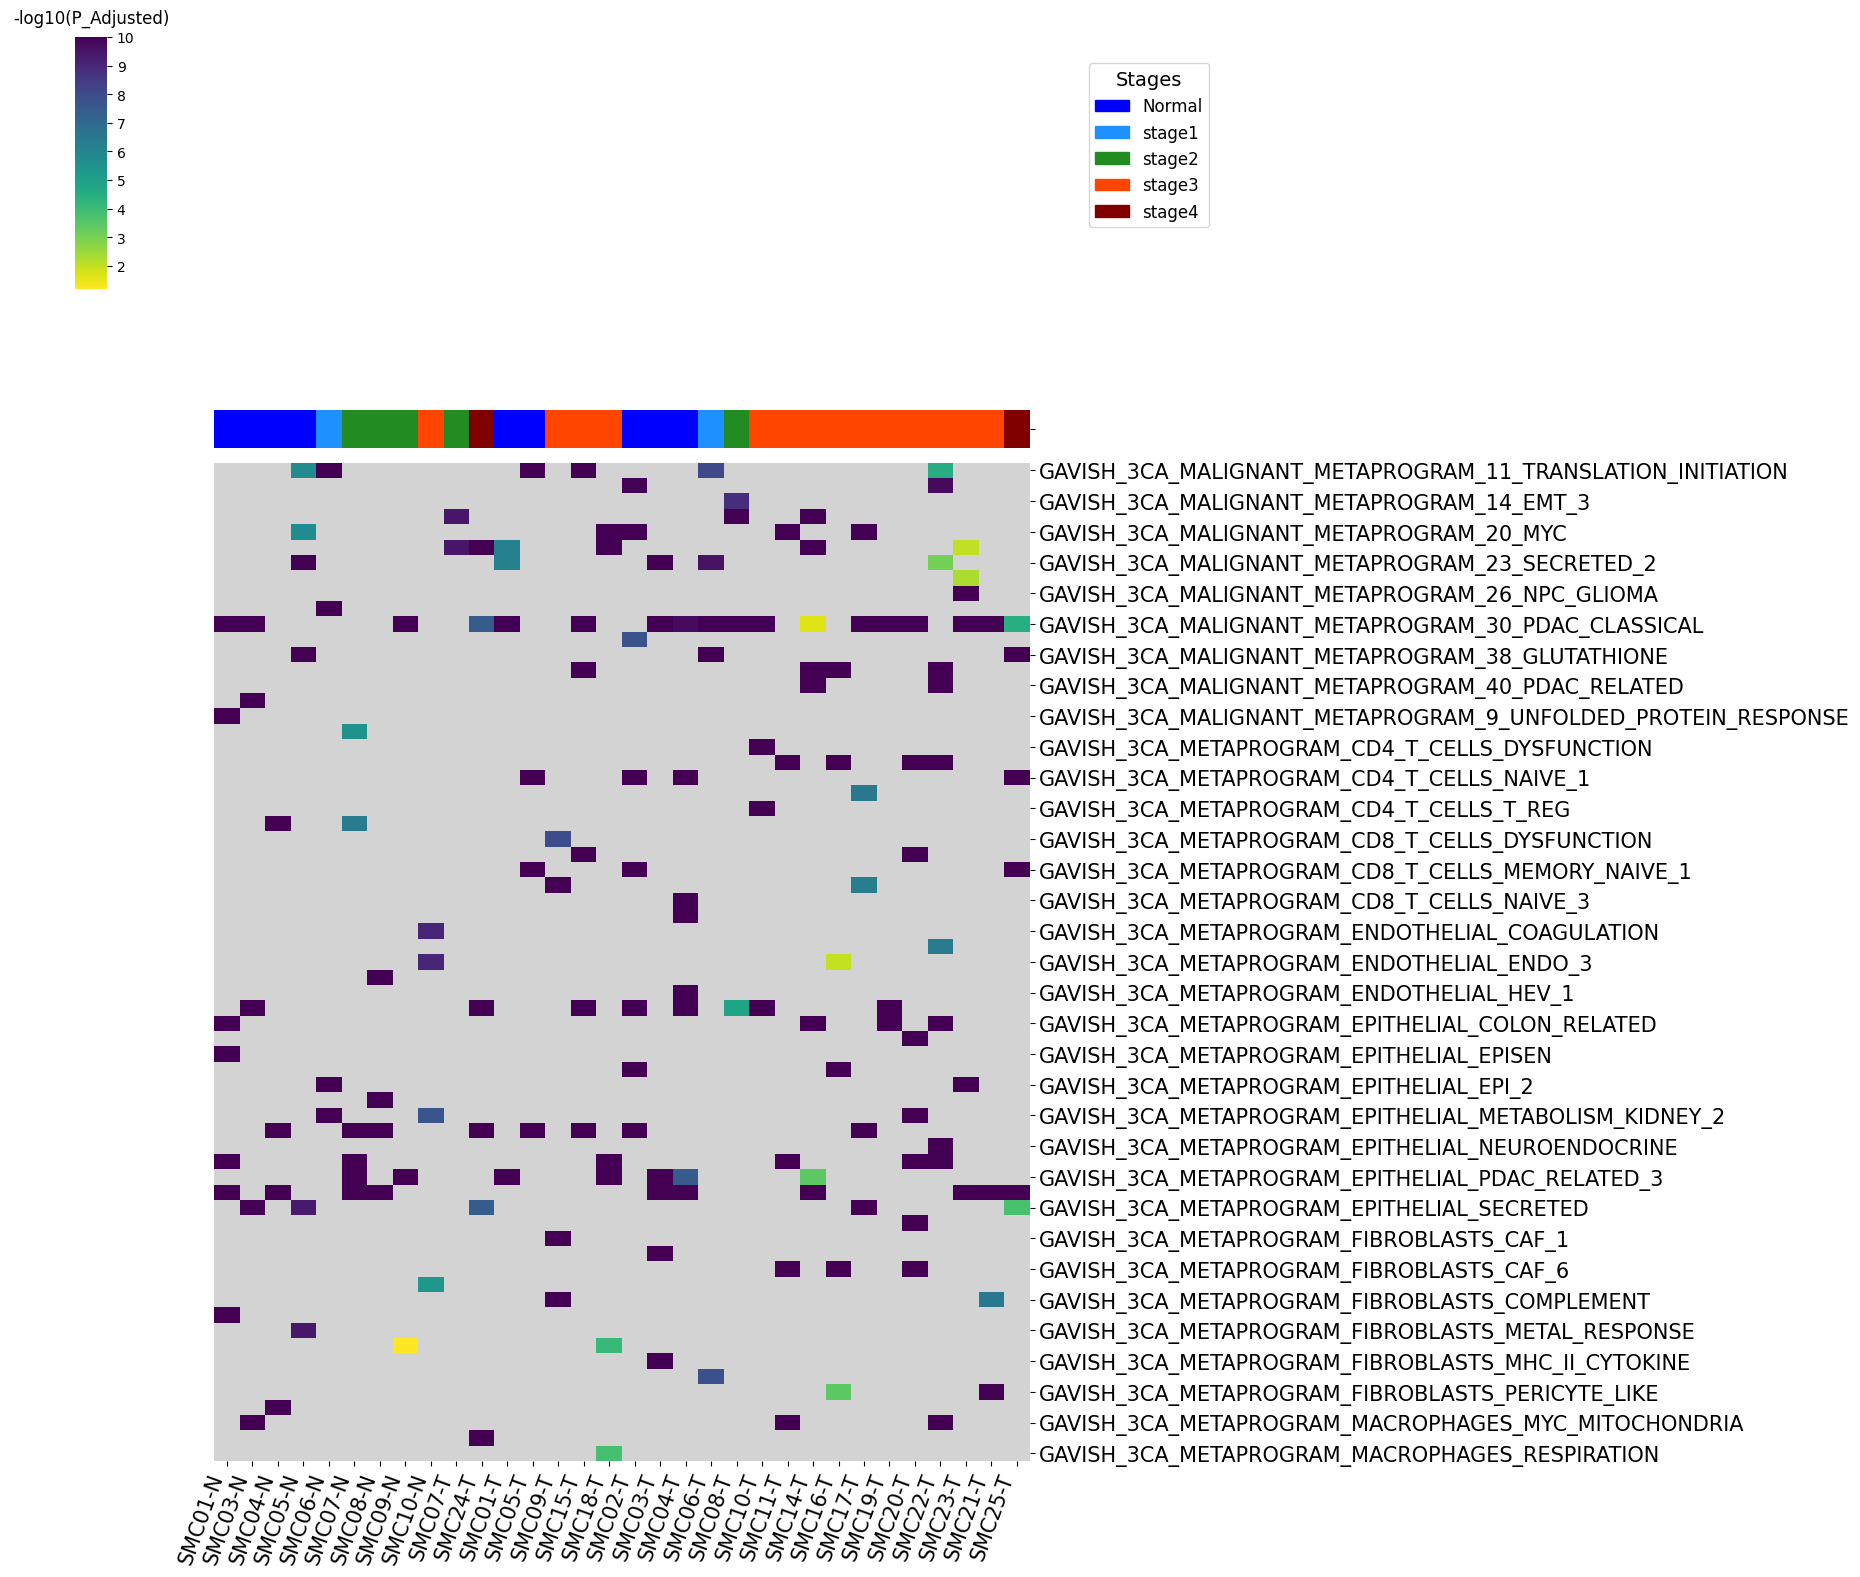

In [45]:
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

stages = (['Normal'] * 9) + (['stage1'] * 2) + (['stage2'] * 5) + (['stage3'] * 14) + (['stage4'] * 2)
sample_info = pd.Series(stages, index=samples)

custom_colors = ["blue", "dodgerblue", "forestgreen", "orangered", "maroon"]
    
# Suppose your groups are sorted in this order:
unique_groups = ['Normal', 'stage1', 'stage2', 'stage3', 'stage4']

# Map groups to your custom colors
palette = dict(zip(unique_groups, custom_colors))

# Transform the stage labels into a list of colors
col_colors = sample_info.map(palette)

heatmap_df = -np.log10(hallmark_func_all_samples_filtered_merged + 1e-10)

g = sns.clustermap(
    heatmap_df, 
    z_score=None,
    col_colors=col_colors, 
    cmap='viridis_r', 
    row_cluster=False,
    col_cluster=False,
    figsize=(16, 14), 
    cbar_pos=(0.05, 0.90, 0.02, 0.18)
)
col_colors_pos = g.ax_col_colors.get_position()
g.ax_heatmap.set_facecolor('lightgrey')
g.ax_heatmap.tick_params(axis='y', labelsize=15)
g.ax_col_colors.set_position([
    col_colors_pos.x0, 
    col_colors_pos.y0 + 0.01, 
    col_colors_pos.width, 
    col_colors_pos.height
])

g.ax_cbar.set_title('-log10(P_Adjusted)', fontsize=12, pad=10)
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=70, 
    fontsize=15,
    horizontalalignment='right'
)

legend_handles = [mpatches.Patch(color=color, label=stage) 
                  for stage, color in palette.items()]

g.ax_heatmap.legend(
    handles=legend_handles, 
    title="Stages", 
    bbox_to_anchor=(1.22, 1.4), 
    loc='upper right',          
    borderaxespad=0,
    fontsize=12,
    title_fontsize=14
)
plt.savefig("/data/subhasis_backup/subhasis/pipeline_testing/functional_characterization_gavish_test/Emerging functions epithelial.pdf", bbox_inches='tight', dpi=300)
plt.show()